<a href="https://colab.research.google.com/github/SarveshMD/colab-notebooks/blob/main/mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [56]:
# !pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("oddrationale/mnist-in-csv")
print(path)

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
/kaggle/input/mnist-in-csv


In [57]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [87]:
mnist_train = pd.read_csv(path + "/mnist_train.csv")
mnist_test = pd.read_csv(path + "/mnist_test.csv")

y_train = torch.from_numpy(mnist_train["label"].to_numpy()).to(device)
X_train = torch.from_numpy(mnist_train.drop("label", axis=1).to_numpy()).float().to(device) / 255

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=1/6, random_state=13, shuffle=True, stratify=y_train)

y_test = torch.from_numpy(mnist_test["label"].to_numpy()).to(device)
X_test = torch.from_numpy(mnist_test.drop("label", axis=1).to_numpy()).float().to(device) / 255

In [88]:
print(X_train.shape, X_test.shape)
print(X_val.shape, y_val.shape)
print(y_train.unique(return_counts=True), y_val.unique(return_counts=True), y_test.unique(return_counts=True))

torch.Size([50000, 784]) torch.Size([10000, 784])
torch.Size([10000, 784]) torch.Size([10000])
(tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), tensor([4936, 5618, 4965, 5109, 4868, 4517, 4932, 5221, 4876, 4958])) (tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), tensor([ 987, 1124,  993, 1022,  974,  904,  986, 1044,  975,  991])) (tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), tensor([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009]))


In [158]:
model_0 = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256,256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

In [159]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  return correct / y_true.shape[0] * 100

In [160]:
with torch.inference_mode():
  y_pred = model_0(X_val)

y_pred = torch.argmax(y_pred, dim=1)
print(accuracy_fn(y_val, y_pred))

5.41


In [161]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=64)

In [162]:
print(X_train.dtype)
print(X_train.min(), X_train.max())
print(X_train.dtype)
print(X_train.shape)

print(X_train.min())
print(X_train.max())

print(y_train.dtype)
print(torch.unique(y_train))

X_batch, y_batch = next(iter(train_loader))
print(X_batch.shape, y_batch.shape)

torch.float32
tensor(0.) tensor(1.)
torch.float32
torch.Size([50000, 784])
tensor(0.)
tensor(1.)
torch.int64
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
torch.Size([64, 784]) torch.Size([64])


## Training Loop

In [163]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)
import copy

In [164]:
def train_model(
        model,
        train_loader,
        val_loader,
        loss_fn,
        optimizer,
        epochs=10,
        device="cpu"
):

    epoch_counts = []
    train_loss_history = []
    val_loss_history = []
    val_accuracy_history = []
    best_val_loss = float("inf")
    best_model_state = None

    model = model.to(device)

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss/len(train_loader)

        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.inference_mode():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_logits = model(X_batch)
                val_loss = loss_fn(val_logits, y_batch)

                running_val_loss += val_loss.item()

                val_preds = torch.argmax(val_logits, dim=1)
                total += y_batch.size(0)
                correct += torch.eq(y_batch, val_preds).sum().item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_accuracy = (correct / total) * 100

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"--> Saved current state. Val Loss: {avg_val_loss}")

        epoch_counts.append(epoch)
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_val_loss)
        val_accuracy_history.append(val_accuracy)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f} | Validation Acc: {val_accuracy:.2f}%")

    history = {
        "epoch_counts": epoch_counts,
        "train_loss_history": train_loss_history,
        "val_loss_history": val_loss_history,
        "val_accuracy_history": val_accuracy_history
    }

    return history, best_model_state, best_val_loss

In [165]:
results, best_model_state, best_val_loss = train_model(
    model_0,
    train_loader,
    val_loader,
    loss_fn,
    optimizer
)

--> Saved current state. Val Loss: 0.1680914113760754
Epoch 1/10 | Train Loss: 0.3079 | Validation Loss: 0.1681 | Validation Acc: 94.97%
--> Saved current state. Val Loss: 0.10508582411203415
Epoch 2/10 | Train Loss: 0.1113 | Validation Loss: 0.1051 | Validation Acc: 97.00%
--> Saved current state. Val Loss: 0.09356391791752569
Epoch 3/10 | Train Loss: 0.0764 | Validation Loss: 0.0936 | Validation Acc: 97.37%
Epoch 4/10 | Train Loss: 0.0569 | Validation Loss: 0.0936 | Validation Acc: 97.44%
Epoch 5/10 | Train Loss: 0.0433 | Validation Loss: 0.1251 | Validation Acc: 96.67%
Epoch 6/10 | Train Loss: 0.0336 | Validation Loss: 0.0953 | Validation Acc: 97.25%
Epoch 7/10 | Train Loss: 0.0304 | Validation Loss: 0.0993 | Validation Acc: 97.50%
Epoch 8/10 | Train Loss: 0.0238 | Validation Loss: 0.0966 | Validation Acc: 97.70%
--> Saved current state. Val Loss: 0.08943379800440447
Epoch 9/10 | Train Loss: 0.0219 | Validation Loss: 0.0894 | Validation Acc: 97.72%
Epoch 10/10 | Train Loss: 0.0193 |

In [167]:
def plot_learning_curves(epoch_counts, train_loss_history, val_loss_history, val_accuracy_history):
    fig, ax = plt.subplots(1,2)

    # Losses
    ax[0].plot(epoch_counts, train_loss_history, label="Train Loss")
    ax[0].plot(epoch_counts, val_loss_history, label="Validation Loss")
    ax[0].set_title("Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    # Accuracy
    ax[1].plot(epoch_counts, val_accuracy_history, label="Validation Accuracy")
    ax[1].set_title("Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy (%)")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

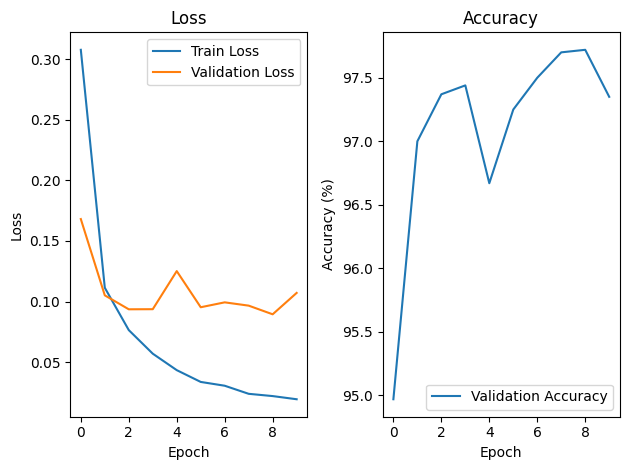

In [168]:
plot_learning_curves(**results)

In [169]:
def test_performance(model, X_test, y_test):
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_probs = torch.softmax(test_logits, dim=1)
        test_preds = torch.argmax(test_logits, dim=1)
        acc = accuracy_fn(y_test, test_preds)

    print(test_loss)
    print(test_probs[0])
    print(test_preds[:5])
    print(y_test[:5])
    print(f"Accuracy: {acc}%\n")

    conf = confusion_matrix(y_test, test_preds)
    metrics = classification_report(y_test, test_preds)

    print(conf)
    print(metrics)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf)
    disp.plot()
    plt.show()

tensor(0.0825)
tensor([3.0143e-12, 1.3490e-07, 1.3838e-07, 4.5061e-07, 1.6087e-12, 7.6527e-11,
        2.2434e-17, 1.0000e+00, 5.9148e-10, 3.6948e-08])
tensor([7, 2, 1, 0, 4])
tensor([7, 2, 1, 0, 4])
Accuracy: 97.86%

[[ 969    0    1    1    1    0    1    3    3    1]
 [   1 1128    2    0    0    0    2    0    2    0]
 [   1    1 1007    4    3    0    1   10    5    0]
 [   1    0    1  999    0    1    0    2    3    3]
 [   2    0    3    0  964    0    4    2    0    7]
 [   2    0    0   15    3  851    7    0    9    5]
 [   2    2    1    0   17    2  930    0    3    1]
 [   0    4    8    2    0    0    0 1012    1    1]
 [   2    0    4   10    3    1    4    3  944    3]
 [   1    3    0    5   10    2    0    5    1  982]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.96      0.99 

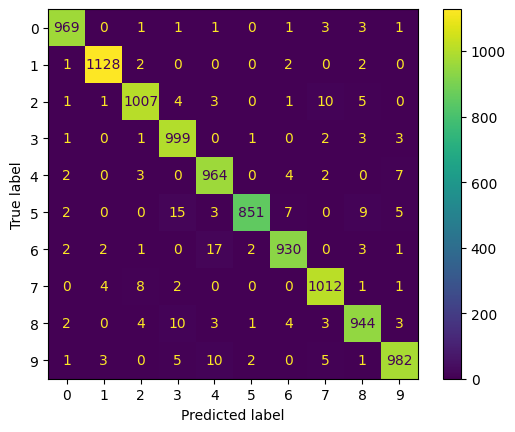

In [171]:
model_0.load_state_dict(best_model_state)
test_performance(model_0, X_test, y_test)